# Comparing SimpleML and scikit-learn's SGDClassifier on synthetic and real datasets

In [ ]:
# Importinf necessary libraries
import pandas as pd

# Importing SimpleML and scikit-learn modules
from simpleml.pipeline import make_pipeline as sml_make_pipeline
import simpleml.preprocessing as sml_preprocessing
import simpleml.linear_models as sml_linear_models
import simpleml.metrics as sml_metrics
import sklearn as sk

from sklearn.datasets import make_classification

In [3]:
# Generating a synthetic classification dataset
X, y = make_classification(
    n_samples=500,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['target'] = y

In [4]:
def evaluate_model(model_name, dataset, y_test, predictions):
    return {
        "model": model_name,
        "dataset": dataset,
        "accuracy": sml_metrics.accuracy_score(y_test, predictions),
        "precision": sml_metrics.precision_score(y_test, predictions),
        "recall": sml_metrics.recall_score(y_test, predictions),
        "f1_score": sml_metrics.f1_score(y_test, predictions)
    }

In [5]:
# Splitting the dataset into training and testing sets
# I used sickit-learn's train_test_split function instead of SimpleML's
# because it allows us to stratify the split based on the target variable
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# pipleines for both SimpleML and scikit-learn
sml_pipeline = sml_make_pipeline(
    sml_preprocessing.StandardScaler(),
    sml_linear_models.SGDClassifier(random_state=42, learning_rate="invscaling" , eta0=0.01)
)

sk_pipeline = sk.pipeline.make_pipeline(
    sk.preprocessing.StandardScaler(),
    sk.linear_model.SGDClassifier(random_state=42, learning_rate="invscaling", eta0=0.01)
)
sml_model = sml_pipeline.fit(X_train, y_train)
sk_model = sk_pipeline.fit(X_train, y_train)

sml_predictions = sml_model.predict(X_test)
sk_predictions = sk_model.predict(X_test)

In [6]:
results = [
    evaluate_model("SimpleML SGDClassifier", "synthetic_classification", y_test, sml_predictions),
    evaluate_model("Sklearn SGDClassifier", "synthetic_classification", y_test, sk_predictions)
]

In [7]:
from sklearn.datasets import load_breast_cancer
breast_cancer_data = load_breast_cancer()

X , y = breast_cancer_data.data, breast_cancer_data.target

In [8]:
# same here but for the breast cancer dataset
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sml_pipeline = sml_make_pipeline(
    sml_preprocessing.StandardScaler(),
    sml_linear_models.SGDClassifier(random_state=42, learning_rate="invscaling" , eta0=0.01)
)

sk_pipeline = sk.pipeline.make_pipeline(
    sk.preprocessing.StandardScaler(),
    sk.linear_model.SGDClassifier(random_state=42, learning_rate="invscaling", eta0=0.01)
)

sml_model = sml_pipeline.fit(X_train, y_train)
sk_model = sk_pipeline.fit(X_train, y_train)

sml_predictions = sml_model.predict(X_test)
sk_predictions = sk_model.predict(X_test)

In [9]:
results.append(evaluate_model("SimpleML SGDClassifier", "breast_cancer", y_test, sml_predictions))
results.append(evaluate_model("Sklearn SGDClassifier", "breast_cancer", y_test, sk_predictions))

In [10]:
results_df = pd.DataFrame(results)
results_df

,model,dataset,accuracy,precision,recall,f1_score
0,SimpleML SGDClassifier,synthetic_classification,0.860000,0.891304,0.820000,0.854167
1,Sklearn SGDClassifier,synthetic_classification,0.870000,0.893617,0.840000,0.865979
2,SimpleML SGDClassifier,breast_cancer,0.964912,0.972222,0.972222,0.972222
3,Sklearn SGDClassifier,breast_cancer,0.964912,0.959459,0.986111,0.972603


### It's clear that both SimpleML and scikit-learn perform similarly on both datasets, with comparable accuracy, precision, recall, and F1 scores. This suggests that SimpleML's implementation of the SGDClassifier is effective

In [11]:
from sklearn.metrics import confusion_matrix

print("SimpleML confusion matrix:")
print(confusion_matrix(y_test, sml_predictions))

print("sklearn confusion matrix:")
print(confusion_matrix(y_test, sk_predictions))

SimpleML confusion matrix:
[[40  2]
 [ 2 70]]
sklearn confusion matrix:
[[39  3]
 [ 1 71]]


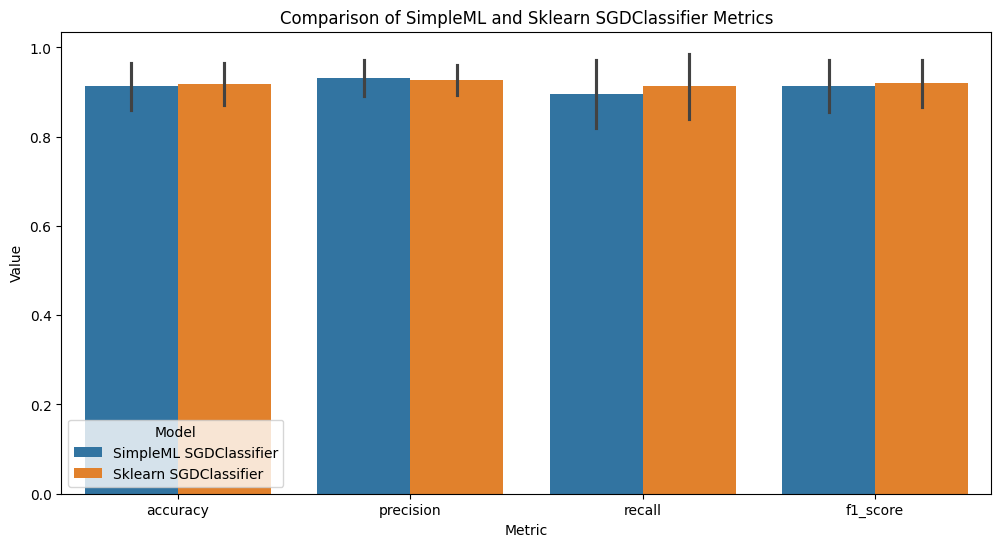

In [12]:
# plotting a grouped bar chart to compare the metrics of both models
import matplotlib.pyplot as plt
import seaborn as sns
# melt the results dataframe for easier plotting
melted_results = results_df.melt(id_vars=["model", "dataset"], var_name="metric", value_name="value")
plt.figure(figsize=(12, 6))
sns.barplot(data=melted_results, x="metric", y="value", hue="model")
plt.title("Comparison of SimpleML and Sklearn SGDClassifier Metrics")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.legend(title="Model")
plt.show()

### Not surprising that both gave the same confusion matrix since they have nearly the same predictions

## In Conclusion, this notebook shows that SimpleML's implementation of the SGDClassifier performs similarly to scikit-learn's implementation on both the synthetic and breast cancer datasets, however due to hyperparameter tuning and the nature of the datasets, the performance may vary. in this case, I didn't use the default hyperparameters for both models, especially for sickit-learn, which may have affected the performance.